# Experiment 1: Effect of Training Data Size

## Research Question

How does the amount of training data affect the generalization
performance of Linear Regression on the California Housing dataset?

## Hypothesis

Increasing the amount of training data will improve out-of-sample
performance, although the improvement may diminish as more training
data becomes available.

## Experimental Principle

Only the amount of training data will be changed. The following will
remain constant:

- Feature set
- Preprocessing strategy
- Linear Regression model
- Validation data
- Test data
- Evaluation metrics

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\H'
<>:1: SyntaxWarning: invalid escape sequence '\H'
C:\Users\HP\AppData\Local\Temp\ipykernel_14720\4013469833.py:1: SyntaxWarning: invalid escape sequence '\H'
  df = pd.read_csv("E:\House Price Prediction ML Project\Data\Raw\housing.csv")


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [18]:
X = df.drop(columns=["median_house_value"])
y =df['median_house_value']

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

#Split the raw data inot train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=12)

#Seprate Numerical Features and Categorical Feature
numerical_features = X_train.select_dtypes(include=('int64', 'float64')).columns
categorical_features = X_train.select_dtypes(include=('str','object')).columns

#Build the preprocessing pipeline

# Numerical Pipeline
numerical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scalar', StandardScaler())
])

# Categorical Pipeline (FIXED)
categorical_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')), # Added to handle missing strings
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)) 
])

# Applying the Transformation 
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('Cat', categorical_pipeline, categorical_features)
])


#Initializing the pipeline
baseline_lr = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

# Experimental Data Split

To ensure that the experiments provide reliable estimates of model
generalization and avoid data leakage, the dataset is divided into a
development set and a held-out test set. The development set is further
divided into a training pool and a fixed validation set for Experiment 1.

The held-out test set remains completely untouched throughout the
experimental process and is used only for the final evaluation of the
selected modeling approach.

## 1. Initial Train-Test Split

The original dataset is first divided into an 80% development set and a
20% held-out test set.

```text
Original Dataset
       │
       ├──────────────────┐
       ↓                  ↓
Development Set        Test Set
      80%                 20%
       │                   │
       │              Held out until
       │              final evaluation
       ↓
 Used for experiments

## 2. Development-Validation Split

For Experiment 1, the 80% development set is further divided into an
80% training pool and a 20% fixed validation set.

```text
Development Set (80%)
          │
          ├──────────────────┐
          ↓                  ↓
   Training Pool         Validation Set
        80%                   20%
          │
          │
     Used to create
     different training
     sizes

## 3. Training-Size Experiment

Different proportions of the training pool will be used to train separate
Linear Regression models.

```text
Training Pool
      │
      ├── 20% ──┐
      ├── 40% ──┤
      ├── 60% ──┼──→ Same Validation Set
      └── 80% ──┘

In [22]:
from sklearn.model_selection import train_test_split

#x_train_pool, y_train_pool -> 80% of original training data, used to train machine learning model.
#x_val, y_val -> 20% of original training data (test_size=0.20), held back to tune hyperparameters and evaluate performance before final testing.

x_train_pool, x_val, y_train_pool, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

### Define training sizes

In [23]:
training_fractions = [0.20, 0.40, 0.60, 0.80]

### Run the experiment

In [27]:
from sklearn.base import clone
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

results = []

for fraction in training_fractions:
    #Do train test split for different training data sizes
    x_subset, _, y_subset, _ = train_test_split(x_train_pool, y_train_pool, train_size=fraction, random_state=12)

    model = clone(baseline_lr)
    model.fit(x_subset,y_subset)

    
    y_train_pred = model.predict(x_subset)
    y_val_pred = model.predict(x_val)

    train_rmse = root_mean_squared_error(y_subset,y_train_pred)
    val_rmse = root_mean_squared_error(y_val, y_val_pred)

    train_mae = mean_absolute_error(y_subset,y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)

    train_r2 = r2_score(y_subset,y_train_pred)
    val_r2 = r2_score(y_val, y_val_pred)

    results.append({
        "Training_fraction": fraction,
        "Training_samples": len(x_subset),
        "Train_RMSE": train_rmse,
        "Validation_RMSE": val_rmse,
        "Train_MAE": train_mae,
        "Validation_MAE": val_mae,
        "Train_R2": train_r2,
        "Validation_R2": val_r2
    })


    

In [28]:
results_df = pd.DataFrame(results)
results_df

,Training_fraction,Training_samples,Train_RMSE,Validation_RMSE,Train_MAE,Validation_MAE,Train_R2,Validation_R2
0,0.2,2641,68781.721792,67704.595051,49676.098425,49357.080810,0.643458,0.649784
1,0.4,5283,68632.927778,67645.317199,49807.720369,49010.569245,0.636954,0.650397
2,0.6,7925,67850.814338,67655.860539,49496.974556,49011.953165,0.643827,0.650288
3,0.8,10567,68121.460981,67634.031185,49661.444121,49029.049506,0.644235,0.650513


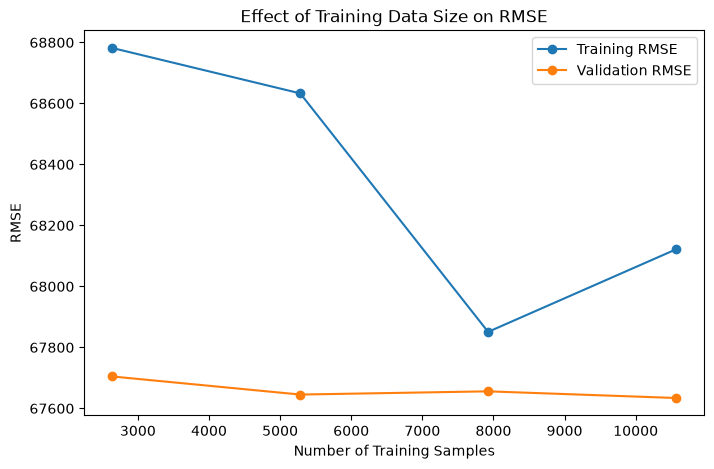

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Training_samples"],
    results_df["Train_RMSE"],
    marker="o",
    label="Training RMSE"
)

plt.plot(
    results_df["Training_samples"],
    results_df["Validation_RMSE"],
    marker="o",
    label="Validation RMSE"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("RMSE")
plt.title("Effect of Training Data Size on RMSE")
plt.legend()

plt.show()

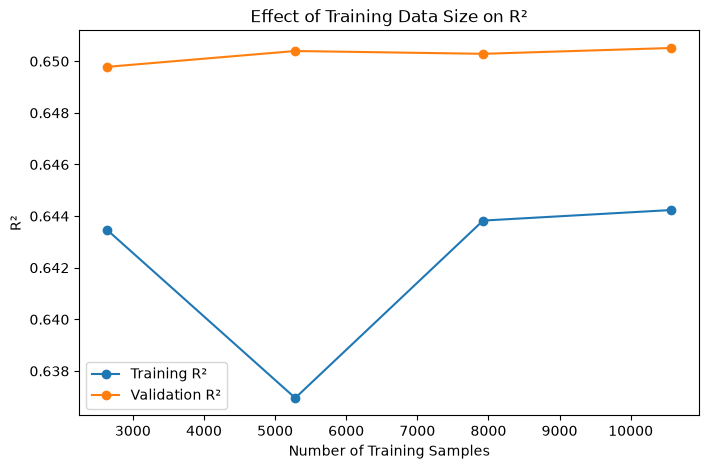

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Training_samples"],
    results_df["Train_R2"],
    marker="o",
    label="Training R²"
)

plt.plot(
    results_df["Training_samples"],
    results_df["Validation_R2"],
    marker="o",
    label="Validation R²"
)

plt.xlabel("Number of Training Samples")
plt.ylabel("R²")
plt.title("Effect of Training Data Size on R²")
plt.legend()

plt.show()

## Experiment Results

The validation performance of Linear Regression remained remarkably
stable as the amount of training data increased.

Validation RMSE changed from approximately 67,705 when using 20% of the
training pool to approximately 67,634 when using 80%. Similarly,
validation R² changed only from approximately 0.650 to 0.651.

Therefore, increasing the training data within the tested range produced
only a negligible improvement in out-of-sample performance.

The learning curve suggests that the model reaches a performance plateau
relatively early. This indicates that, for the current Linear Regression
configuration, simply increasing the amount of training data is unlikely
to produce substantial improvements within the tested range.

This result does not imply that additional data can never improve
performance. Rather, it suggests that other factors, such as feature
representation, feature selection, geographic information, or model
complexity, may have a greater influence on predictive performance for
this dataset.

## Hypothesis Evaluation

### H1: Effect of Training Data Size

**Hypothesis:** Increasing the amount of training data will improve
out-of-sample performance, although the improvement may diminish as more
data becomes available.

**Result:** Not strongly supported.

Validation performance remained almost unchanged across the tested
training sizes. Increasing the training data from 20% to 80% of the
training pool produced only a negligible improvement in validation RMSE
and R².

The results therefore suggest that the current Linear Regression model
is not strongly limited by the amount of training data within the tested
range.